In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras

In [3]:
df = pd.read_csv("C:\DL\dbalone.csv")
df

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...,...
4172,4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [4]:
X = df.drop('Rings',axis=1)
X.head()

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight
0,0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150
1,1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070
2,2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210
3,3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155
4,4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055


In [5]:
y = df['Rings']
y.head()

0    15
1     7
2     9
3    10
4     7
Name: Rings, dtype: int64

In [6]:
from sklearn.preprocessing import LabelEncoder

labelencoder=LabelEncoder()
X['Sex']=labelencoder.fit_transform(X['Sex'])

In [7]:
Y = pd.get_dummies(y).values

In [8]:
X = X.values

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

In [10]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape, 

((3341, 9), (3341, 28), (836, 9), (836, 28))

In [11]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD,Adam


model = Sequential()

model.add(Dense(8,input_shape=(9,)))
model.add(Dense(30))
model.add(Dense(30))
model.add(Dense(1))

model.compile(optimizer = 'rmsprop', loss = 'mse', metrics = ['mse'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 8)                 80        
                                                                 
 dense_1 (Dense)             (None, 30)                270       
                                                                 
 dense_2 (Dense)             (None, 30)                930       
                                                                 
 dense_3 (Dense)             (None, 1)                 31        
                                                                 
Total params: 1,311
Trainable params: 1,311
Non-trainable params: 0
_________________________________________________________________


In [17]:
N_EPOCHS = 10

history=model.fit(x=X_train, y=y_train, epochs=N_EPOCHS, batch_size=32,validation_data= (X_test,y_test))
y_pred = model.predict(X_test)

Epoch 1/10
105/105 [==============================] - 0s 4ms/step - loss: 0.6367 - mse: 0.6367 - val_loss: 0.0347 - val_mse: 0.0347
Epoch 2/10
105/105 [==============================] - 0s 2ms/step - loss: 0.6731 - mse: 0.6731 - val_loss: 0.1659 - val_mse: 0.1659
Epoch 3/10
105/105 [==============================] - 0s 3ms/step - loss: 0.8858 - mse: 0.8858 - val_loss: 0.0352 - val_mse: 0.0352
Epoch 4/10
105/105 [==============================] - 0s 3ms/step - loss: 0.0863 - mse: 0.0863 - val_loss: 0.0344 - val_mse: 0.0344
Epoch 5/10
105/105 [==============================] - 0s 3ms/step - loss: 0.7914 - mse: 0.7914 - val_loss: 0.0355 - val_mse: 0.0355
Epoch 6/10
105/105 [==============================] - 0s 3ms/step - loss: 0.6629 - mse: 0.6629 - val_loss: 0.0354 - val_mse: 0.0354
Epoch 7/10
105/105 [==============================] - 0s 2ms/step - loss: 0.1655 - mse: 0.1655 - val_loss: 0.0345 - val_mse: 0.0345
Epoch 8/10
105/105 [==============================] - 0s 3ms/step - loss: 0.

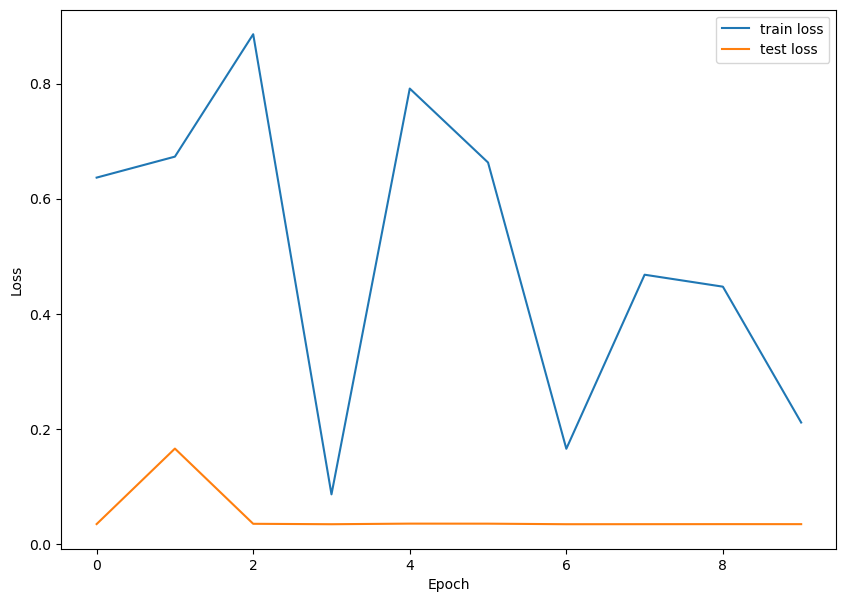

In [18]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,7))
plt.plot(range(N_EPOCHS), history.history['loss'], label='train loss')
plt.plot(range(N_EPOCHS), history.history['val_loss'], label='test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [19]:
model.evaluate(X_test, y_test)

27/27 [==============================] - 0s 3ms/step - loss: 0.0346 - mse: 0.0346


[0.03457433730363846, 0.03457433730363846]